First, we need to import the numpy and matplotlib packages. It'll be necessary to calculate the inner product, create the vectors ("arrays") that will contain the features, and graph the function.

In [26]:
import numpy as np
import matplotlib.pyplot as plt


We need to initialize the array that will represent $X$ the dataset, so each scalar will be a vector $x_1$.

In [17]:
# OR dataset
X = np.array([
    [-1, -1],
    [1, 0],
    [0, 1],
    [1, 1]
])
d = 2

Now, we initialize $y$ that contains the label respectively, and each scalar("label") is indicated as $y_i$.

In [18]:
y = np.array([-1, 1, 1, 1])

The weight vector and $b$ needs to be initialized with $0$ as the values.

In [19]:
w = np.zeros(X.shape[1])
b = 0

We define the function to train the perceptron

In [20]:
def train_perceptron(X, y, epochs=100):
    # d = number of features
    d = X.shape[1]

    w = np.zeros(d)
    b = 0.0

    for epoch in range(epochs):
        mistakes = 0

        for x_i, y_i in zip(X, y):

            # <x_i, w> + b
            score = np.dot(x_i, w) + b

            # y_i(<x_i,w> + b) <= 0
            if y_i * score <= 0:

                # w <- w + y_i*x_i
                w += y_i * x_i

                # b <- b + y_i
                b += y_i

                mistakes += 1

        # Stop if everything was classified correctly
        if mistakes == 0:
            break

    return w, b

Let's define our prediction function

In [21]:
def predict(X, w, b):
    scores = X @ w + b

    return np.where(scores > 0, 1, -1)

Train the perceptron

In [22]:
w, b = train_perceptron(X, y)
print("w:", w)
print("b:", b)

w: [2. 1.]
b: 0.0


Predictions

In [23]:
predictions = predict(X, w, b)
print("predictions:", predictions)

predictions: [-1  1  1  1]


Let's graph the solution

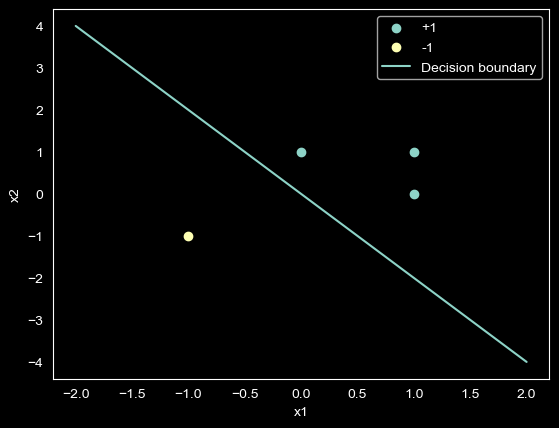

In [27]:
def plot_2d(X, y, w, b):
    x1 = np.linspace(
        X[:, 0].min() - 1,
        X[:, 0].max() + 1,
        200
    )

    # w1*x1 + w2*x2 + b = 0
    x2 = -(w[0] * x1 + b) / w[1]

    plt.scatter(X[y == 1, 0], X[y == 1, 1], label="+1")
    plt.scatter(X[y == -1, 0], X[y == -1, 1], label="-1")

    plt.plot(x1, x2, label="Decision boundary")

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.grid()

    plt.show()

plot_2d(X, y, w, b)